# Visualisasi Data dan Analisis Eksplanatori (BAB IV)
Notebook ini digunakan untuk menghasilkan seluruh visualisasi data pendukung analisis hasil dan pembahasan pada BAB IV Skripsi.

In [4]:
import os
import sys
import warnings
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from scipy import stats

warnings.filterwarnings("ignore")
matplotlib.rcParams["axes.unicode_minus"] = False

# Konfigurasi Path (karena berjalan di folder notebook, naik satu tingkat ke root)
BASE_DIR = Path(os.getcwd()).parent
FEATURES_PATH = BASE_DIR / "processed_data" / "features" / "features_all_dataset.csv"
MERGED_PATH   = BASE_DIR / "processed_data" / "merged"  / "dataset_all_merged.csv"
PREDS_PATH    = BASE_DIR / "results" / "test_predictions.csv"
EVAL_PATH     = BASE_DIR / "results" / "evaluation_per_commodity.csv"
FI_PATH       = BASE_DIR / "results" / "feature_importance.csv"
OUT_DIR       = BASE_DIR / "figures" / "bab4"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Global Style
plt.style.use("seaborn-v0_8-whitegrid")
FONT_FAMILY = "DejaVu Serif"

STYLE_BASE = {
    "font.family":        FONT_FAMILY,
    "font.size":          11,
    "axes.titlesize":     13,
    "axes.titleweight":   "bold",
    "axes.labelsize":     11,
    "axes.labelweight":   "bold",
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "legend.fontsize":    9,
    "legend.framealpha":  0.9,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.15,
}
plt.rcParams.update(STYLE_BASE)

C_BLUE   = "#2166AC"
C_GREEN  = "#1A9641"
C_ORANGE = "#F46D43"
C_RED    = "#D73027"
C_GOLD   = "#FDAE61"
C_GRAY   = "#AAAAAA"
C_DARK   = "#333333"

def save_fig(fig, name):
    path = OUT_DIR / name
    fig.savefig(path, dpi=300, bbox_inches="tight", pad_inches=0.15)
    print(f"Gambar berhasil disimpan ke: {path.name}")
    plt.show()

# Load Data
print("Memuat dataset...")
df_feat = pd.read_csv(FEATURES_PATH, parse_dates=["Tanggal"], low_memory=False)
df_merged = pd.read_csv(MERGED_PATH, parse_dates=["Tanggal"], low_memory=False)
df_preds = pd.read_csv(PREDS_PATH, parse_dates=["Tanggal"], low_memory=False)
df_eval  = pd.read_csv(EVAL_PATH)
df_fi    = pd.read_csv(FI_PATH)
print("Dataset berhasil dimuat.")

Memuat dataset...
Dataset berhasil dimuat.


## Gambar 4.1 — Alur Volume Data ETL
Visualisasi perbandingan jumlah baris per sumber data sebelum dan sesudah tahap resolusi konflik deduplikasi data.

Gambar berhasil disimpan ke: gambar_4_1.png


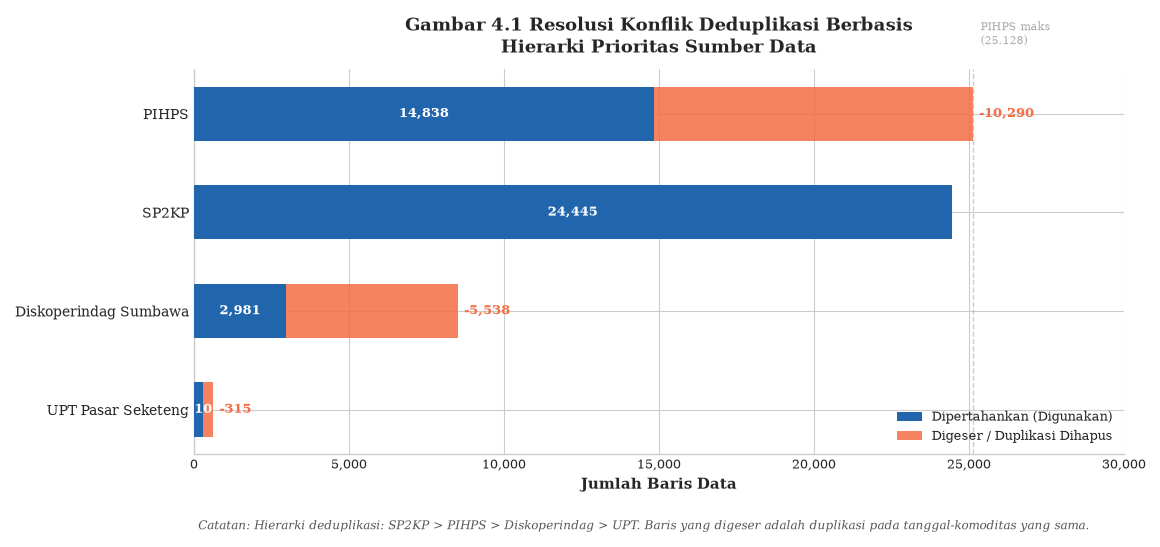

In [5]:
SUMBER_ORDER = ["UPT Pasar Seketeng", "Diskoperindag Sumbawa", "SP2KP", "PIHPS"]
before = {
    "PIHPS": 25128,
    "SP2KP": 24445,
    "Diskoperindag Sumbawa": 8519,
    "UPT Pasar Seketeng": 625,
}
after = {
    "SP2KP": 24445,
    "PIHPS": 14838,
    "Diskoperindag Sumbawa": 2981,
    "UPT Pasar Seketeng": 310,
}
labels = SUMBER_ORDER
kept = [after[s] for s in labels]
removed = [before[s] - after[s] for s in labels]

fig, ax = plt.subplots(figsize=(12, 5))
y_pos = np.arange(len(labels))
bar_h = 0.55

b1 = ax.barh(y_pos, kept, height=bar_h, color=C_BLUE, label="Dipertahankan (Digunakan)", zorder=3)
b2 = ax.barh(y_pos, removed, height=bar_h, left=kept, color=C_ORANGE, label="Digeser / Duplikasi Dihapus", alpha=0.85, zorder=3)

for i, (k, r) in enumerate(zip(kept, removed)):
    ax.text(k / 2, i, f"{k:,}", va="center", ha="center", fontsize=9, color="white", fontweight="bold")
    if r > 0:
        total = k + r
        ax.text(total + 200, i, f"-{r:,}", va="center", ha="left", fontsize=9, color=C_ORANGE, fontweight="bold")

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel("Jumlah Baris Data", fontsize=11, fontweight="bold")
ax.set_title("Gambar 4.1 Resolusi Konflik Deduplikasi Berbasis\nHierarki Prioritas Sumber Data", fontsize=13, fontweight="bold", pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xlim(0, 30000)
ax.legend(loc="lower right", framealpha=0.95, fontsize=9)

ax.axvline(25128, color=C_GRAY, linestyle="--", linewidth=1, zorder=2, alpha=0.6)
ax.text(25128 + 250, len(labels) - 0.05, "PIHPS maks\n(25.128)", fontsize=8, color=C_GRAY, va="top")

fig.text(0.5, -0.04, "Catatan: Hierarki deduplikasi: SP2KP > PIHPS > Diskoperindag > UPT. Baris yang digeser adalah duplikasi pada tanggal-komoditas yang sama.", ha="center", fontsize=8.5, style="italic", color="#555555")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

save_fig(fig, "gambar_4_1.png")

## Gambar 4.2 — Tren Harga 5 Komoditas Pangan Strategis
Tren harga historis bulanan 5 komoditas pangan dari tahun 2021 hingga 2026 beserta penanda bulan suci Ramadan/Lebaran.

Gambar berhasil disimpan ke: gambar_4_2.png


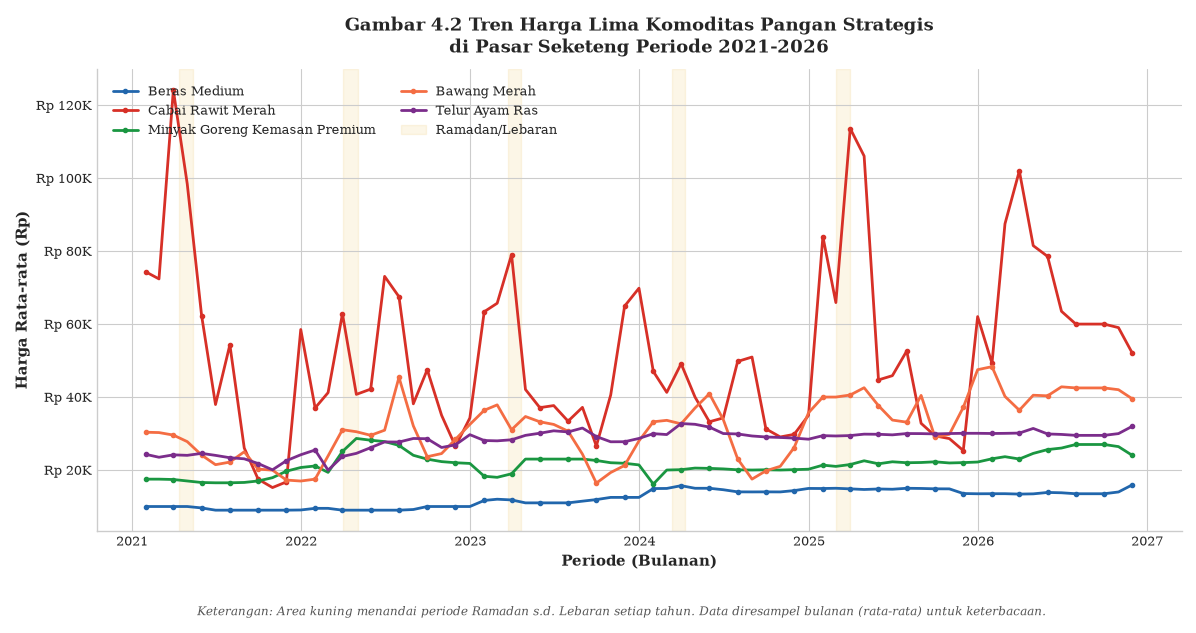

In [6]:
KOMODITAS_5 = ["beras_medium", "cabai_rawit_merah", "minyak_goreng_sawit_kemasan_premium", "bawang_merah", "telur_ayam_ras"]
LABELS_5 = {
    "beras_medium": "Beras Medium",
    "cabai_rawit_merah": "Cabai Rawit Merah",
    "minyak_goreng_sawit_kemasan_premium": "Minyak Goreng Kemasan Premium",
    "bawang_merah": "Bawang Merah",
    "telur_ayam_ras": "Telur Ayam Ras",
}
COLORS_5 = [C_BLUE, C_RED, C_GREEN, C_ORANGE, "#7B2D8B"]
HARGA_COL = "Harga"
KOM_COL = "Komoditas"

RAMADAN_PERIODS = [
    ("2021-04-12", "2021-05-13"),
    ("2022-04-02", "2022-05-03"),
    ("2023-03-23", "2023-04-21"),
    ("2024-03-11", "2024-04-09"),
    ("2025-03-01", "2025-03-30"),
]

fig, ax = plt.subplots(figsize=(14, 6))
for i, kom in enumerate(KOMODITAS_5):
    sub = df_feat[df_feat[KOM_COL] == kom].copy()
    if sub.empty: continue
    sub = sub.sort_values("Tanggal")
    sub_monthly = sub.set_index("Tanggal")[HARGA_COL].resample("ME").mean().dropna()
    ax.plot(sub_monthly.index, sub_monthly.values, color=COLORS_5[i], linewidth=2, label=LABELS_5[kom], marker="o", markersize=3, markevery=2)

for j, (start, end) in enumerate(RAMADAN_PERIODS):
    ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), alpha=0.10, color="#E6A817", zorder=0, label="Ramadan/Lebaran" if j == 0 else "")

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"Rp {x/1000:.0f}K"))
ax.set_xlabel("Periode (Bulanan)", fontsize=11, fontweight="bold")
ax.set_ylabel("Harga Rata-rata (Rp)", fontsize=11, fontweight="bold")
ax.set_title("Gambar 4.2 Tren Harga Lima Komoditas Pangan Strategis\ndi Pasar Seketeng Periode 2021-2026", fontsize=13, fontweight="bold", pad=12)

handles, lbls = ax.get_legend_handles_labels()
ax.legend(handles, lbls, ncol=2, loc="upper left", framealpha=0.95, fontsize=9, borderpad=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(0.5, -0.03, "Keterangan: Area kuning menandai periode Ramadan s.d. Lebaran setiap tahun. Data diresampel bulanan (rata-rata) untuk keterbacaan.", ha="center", fontsize=8.5, style="italic", color="#555555")

save_fig(fig, "gambar_4_2.png")

## Gambar 4.3 — Matriks Korelasi Pearson
Analisis korelasi Pearson antar fitur numerik untuk mendeteksi hubungan antar variabel bebas.

Gambar berhasil disimpan ke: gambar_4_3.png


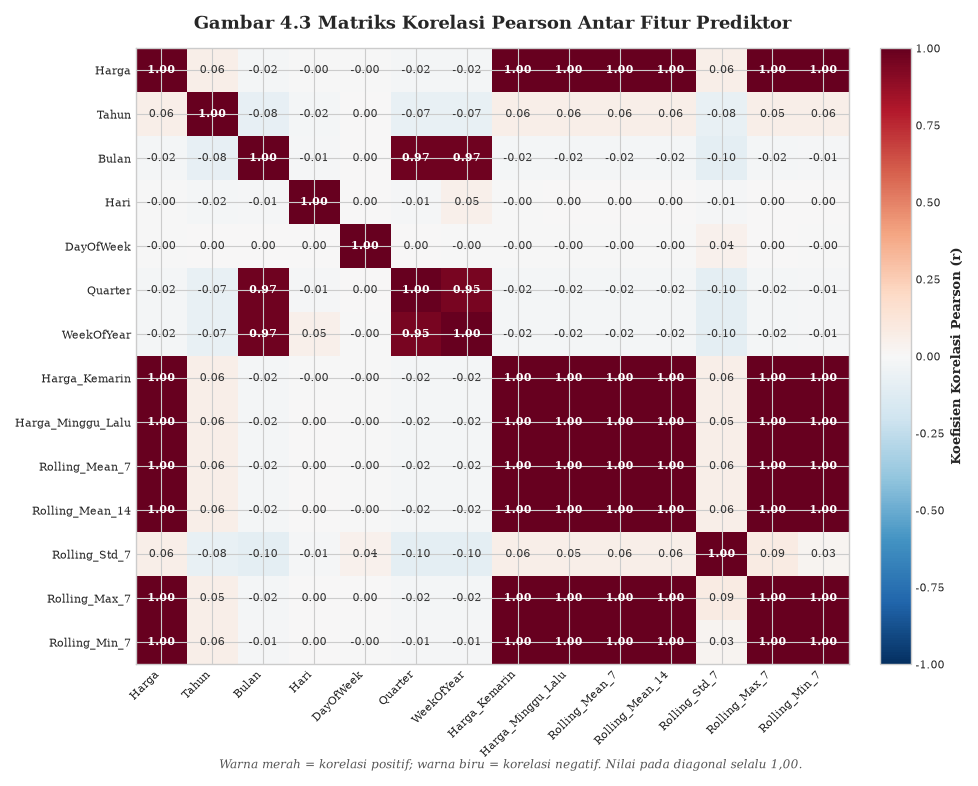

In [7]:
EXCLUDE = {"Tanggal", "Komoditas", "Sumber", "is_imputed"}
num_cols = [c for c in df_feat.select_dtypes(include=np.number).columns if c not in EXCLUDE]
corr = df_feat[num_cols].corr(method="pearson")

fig, ax = plt.subplots(figsize=(10, 8))
from matplotlib.colors import TwoSlopeNorm
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
im = ax.imshow(corr.values, cmap="RdBu_r", norm=norm, aspect="auto")

n = len(corr)
for i in range(n):
    for j in range(n):
        val = corr.iloc[i, j]
        color = "white" if abs(val) > 0.65 else C_DARK
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color=color, fontweight="bold" if abs(val) > 0.8 else "normal")

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)

cbar = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.04)
cbar.set_label("Koefisien Korelasi Pearson (r)", fontsize=9, fontweight="bold")
cbar.ax.tick_params(labelsize=8)

ax.set_title("Gambar 4.3 Matriks Korelasi Pearson Antar Fitur Prediktor", fontsize=13, fontweight="bold", pad=14)
fig.text(0.5, -0.02, "Warna merah = korelasi positif; warna biru = korelasi negatif. Nilai pada diagonal selalu 1,00.", ha="center", fontsize=8.5, style="italic", color="#555555")

save_fig(fig, "gambar_4_3.png")

## Gambar 4.4 — Tingkat Kepentingan Fitur (Feature Importance)
Peringkat kepentingan fitur model Random Forest Regressor berdasarkan Mean Decrease in Impurity (MDI).

Gambar berhasil disimpan ke: gambar_4_4.png


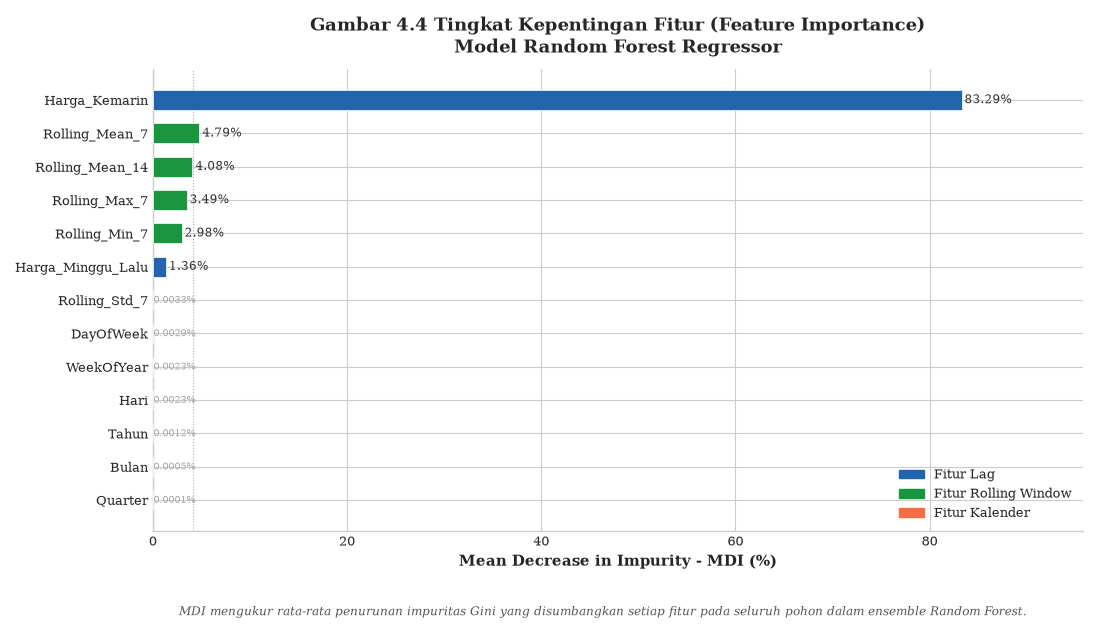

In [8]:
KATEGORI_COLOR = {"Lag": C_BLUE, "Rolling": C_GREEN, "Kalender": C_ORANGE}
KATEGORI_LABEL = {"Lag": "Fitur Lag", "Rolling": "Fitur Rolling Window", "Kalender": "Fitur Kalender"}

df_fi_sorted = df_fi.sort_values("Pct", ascending=True).reset_index(drop=True)
colors = [KATEGORI_COLOR.get(k, C_GRAY) for k in df_fi_sorted["Kategori"]]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(df_fi_sorted["Fitur"], df_fi_sorted["Pct"], color=colors, height=0.6, edgecolor="white", linewidth=0.5, zorder=3)

for bar, val in zip(bars, df_fi_sorted["Pct"]):
    if val >= 1:
        ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2, f"{val:.2f}%", va="center", ha="left", fontsize=8.5, color=C_DARK)
    else:
        ax.text(val + 0.05, bar.get_y() + bar.get_height() / 2, f"{val:.4f}%", va="center", ha="left", fontsize=7.5, color=C_GRAY)

ax.set_xlabel("Mean Decrease in Impurity - MDI (%)", fontsize=11, fontweight="bold")
ax.set_title("Gambar 4.4 Tingkat Kepentingan Fitur (Feature Importance)\nModel Random Forest Regressor", fontsize=13, fontweight="bold", pad=12)

legend_patches = [mpatches.Patch(color=v, label=KATEGORI_LABEL[k]) for k, v in KATEGORI_COLOR.items()]
ax.legend(handles=legend_patches, loc="lower right", framealpha=0.95, fontsize=9)
ax.set_xlim(0, df_fi_sorted["Pct"].max() * 1.15)
ax.axvline(df_fi_sorted["Pct"].max() * 0.05, color=C_GRAY, linestyle=":", linewidth=0.8)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.text(0.5, -0.03, "MDI mengukur rata-rata penurunan impuritas Gini yang disumbangkan setiap fitur pada seluruh pohon dalam ensemble Random Forest.", ha="center", fontsize=8.5, style="italic", color="#555555")

save_fig(fig, "gambar_4_4.png")

## Gambar 4.5 — Harga Aktual vs Prediksi (Cabai Rawit Merah)
Visualisasi perbandingan prediksi model vs harga riil aktual pada data pengujian.

Gambar berhasil disimpan ke: gambar_4_5.png


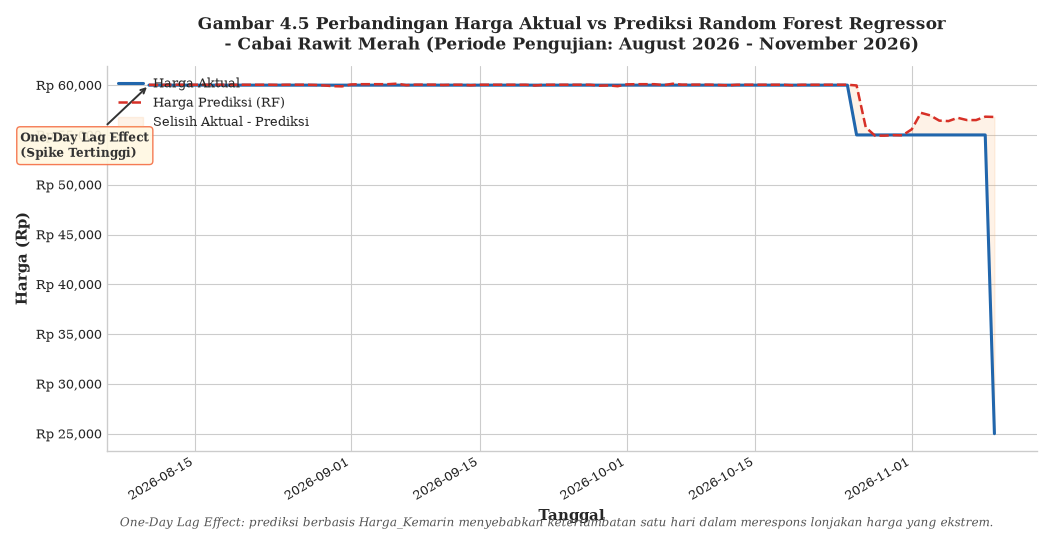

In [9]:
TARGET_KOM = "cabai_rawit_merah"
ZOOM_MONTHS = 3
df_c = df_preds[df_preds["Komoditas"] == TARGET_KOM].copy()

if df_c.empty:
    TARGET_KOM = df_preds["Komoditas"].unique()[0]
    df_c = df_preds[df_preds["Komoditas"] == TARGET_KOM].copy()

df_c = df_c.sort_values("Tanggal")
last_date  = df_c["Tanggal"].max()
start_date = last_date - pd.DateOffset(months=ZOOM_MONTHS)
df_c_zoom  = df_c[df_c["Tanggal"] >= start_date]
if df_c_zoom.empty:
    df_c_zoom = df_c.tail(90)
ZOOM_START = str(df_c_zoom["Tanggal"].min().date())
ZOOM_END   = str(df_c_zoom["Tanggal"].max().date())

fig, ax = plt.subplots(figsize=(12, 5))

if "Harga" in df_c.columns and "y_pred" in df_c.columns:
    ACTUAL_COL = "Harga"
    PRED_COL   = "y_pred"
else:
    _actual_cands = [c for c in df_c.columns if any(k in c.lower() for k in ["aktual", "actual", "y_true", "harga_aktual"])]
    _pred_cands   = [c for c in df_c.columns if any(k in c.lower() for k in ["prediksi", "y_pred", "harga_pred"])]
    ACTUAL_COL = _actual_cands[0]
    PRED_COL   = _pred_cands[0]

ax.plot(df_c_zoom["Tanggal"], df_c_zoom[ACTUAL_COL], color=C_BLUE, linewidth=2.2, linestyle="-", label="Harga Aktual", zorder=4)
ax.plot(df_c_zoom["Tanggal"], df_c_zoom[PRED_COL], color=C_RED, linewidth=1.8, linestyle="--", label="Harga Prediksi (RF)", zorder=4)

ax.fill_between(df_c_zoom["Tanggal"], df_c_zoom[ACTUAL_COL], df_c_zoom[PRED_COL], alpha=0.15, color=C_GOLD, label="Selisih Aktual - Prediksi")

idx_max = df_c_zoom[ACTUAL_COL].idxmax()
spike_date  = df_c_zoom.loc[idx_max, "Tanggal"]
spike_price = df_c_zoom.loc[idx_max, ACTUAL_COL]

ax.annotate(
    "One-Day Lag Effect\n(Spike Tertinggi)",
    xy=(spike_date, spike_price),
    xytext=(spike_date - pd.Timedelta(days=14), spike_price * 0.88),
    arrowprops=dict(arrowstyle="->", color=C_DARK, lw=1.4),
    fontsize=8.5, color=C_DARK, fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", fc="#FFF8E1", ec=C_ORANGE, alpha=0.9),
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"Rp {x:,.0f}"))
ax.set_xlabel("Tanggal", fontsize=11, fontweight="bold")
ax.set_ylabel("Harga (Rp)", fontsize=11, fontweight="bold")
zoom_label = f"{pd.to_datetime(ZOOM_START).strftime('%B %Y')} - {pd.to_datetime(ZOOM_END).strftime('%B %Y')}"
ax.set_title(f"Gambar 4.5 Perbandingan Harga Aktual vs Prediksi Random Forest Regressor\n- Cabai Rawit Merah (Periode Pengujian: {zoom_label})", fontsize=12, fontweight="bold", pad=12)
ax.legend(loc="upper left", framealpha=0.95, fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.xticks(rotation=30, ha="right")

fig.text(0.5, -0.04, "One-Day Lag Effect: prediksi berbasis Harga_Kemarin menyebabkan keterlambatan satu hari dalam merespons lonjakan harga yang ekstrem.", ha="center", fontsize=8.5, style="italic", color="#555555")

save_fig(fig, "gambar_4_5.png")

## Gambar 4.6 — Distribusi Residual Galat
Analisis visual bentuk sebaran residual model Random Forest Regressor dibandingkan terhadap distribusi normal.

Gambar berhasil disimpan ke: gambar_4_6.png


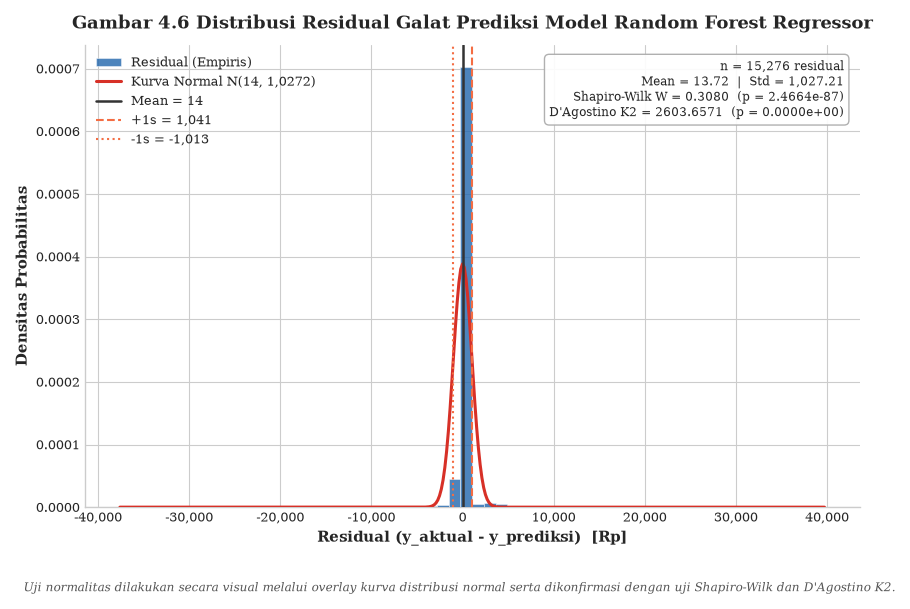

In [10]:
if "is_real" in df_preds.columns:
    df_real = df_preds[df_preds["is_real"] == True].copy()
else:
    df_real = df_preds.copy()

residuals = df_real[ACTUAL_COL] - df_real[PRED_COL]
residuals = residuals.dropna()

mu    = residuals.mean()
sigma = residuals.std()

fig, ax = plt.subplots(figsize=(10, 6))
n_bins = min(60, max(30, len(residuals) // 10))
counts, bins, patches = ax.hist(residuals, bins=n_bins, color=C_BLUE, edgecolor="white", linewidth=0.4, alpha=0.80, density=True, label="Residual (Empiris)", zorder=3)

x_range = np.linspace(residuals.min(), residuals.max(), 400)
pdf_norm = stats.norm.pdf(x_range, mu, sigma)
ax.plot(x_range, pdf_norm, color=C_RED, linewidth=2.2, label=f"Kurva Normal N({mu:,.0f}, {sigma:,.0f}2)", zorder=4)

ax.axvline(mu, color=C_DARK, linewidth=1.8, linestyle="-", label=f"Mean = {mu:,.0f}", zorder=5)
ax.axvline(mu + sigma, color=C_ORANGE, linewidth=1.5, linestyle="--", label=f"+1s = {mu+sigma:,.0f}", zorder=5)
ax.axvline(mu - sigma, color=C_ORANGE, linewidth=1.5, linestyle=":", label=f"-1s = {mu-sigma:,.0f}", zorder=5)

sample_n = min(5000, len(residuals))
sample_r = residuals.sample(sample_n, random_state=42)
stat_sw, p_sw = stats.shapiro(sample_r)
stat_k2, p_k2 = stats.normaltest(sample_r)

note_text = f"n = {len(residuals):,} residual\nMean = {mu:,.2f}  |  Std = {sigma:,.2f}\nShapiro-Wilk W = {stat_sw:.4f}  (p = {p_sw:.4e})\nD'Agostino K2 = {stat_k2:.4f}  (p = {p_k2:.4e})"
ax.text(0.98, 0.97, note_text, transform=ax.transAxes, va="top", ha="right", fontsize=8.5, bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=C_GRAY, alpha=0.92))

ax.set_xlabel("Residual (y_aktual - y_prediksi)  [Rp]", fontsize=11, fontweight="bold")
ax.set_ylabel("Densitas Probabilitas", fontsize=11, fontweight="bold")
ax.set_title("Gambar 4.6 Distribusi Residual Galat Prediksi Model Random Forest Regressor", fontsize=13, fontweight="bold", pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(loc="upper left", framealpha=0.95, fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(0.5, -0.03, "Uji normalitas dilakukan secara visual melalui overlay kurva distribusi normal serta dikonfirmasi dengan uji Shapiro-Wilk dan D'Agostino K2.", ha="center", fontsize=8.5, style="italic", color="#555555")

save_fig(fig, "gambar_4_6.png")

## Gambar 4.7 — Nilai MAPE Per Komoditas
Perbandingan nilai rata-rata persentase galat mutlak (MAPE) untuk seluruh komoditas pangan.

Gambar berhasil disimpan ke: gambar_4_7.png


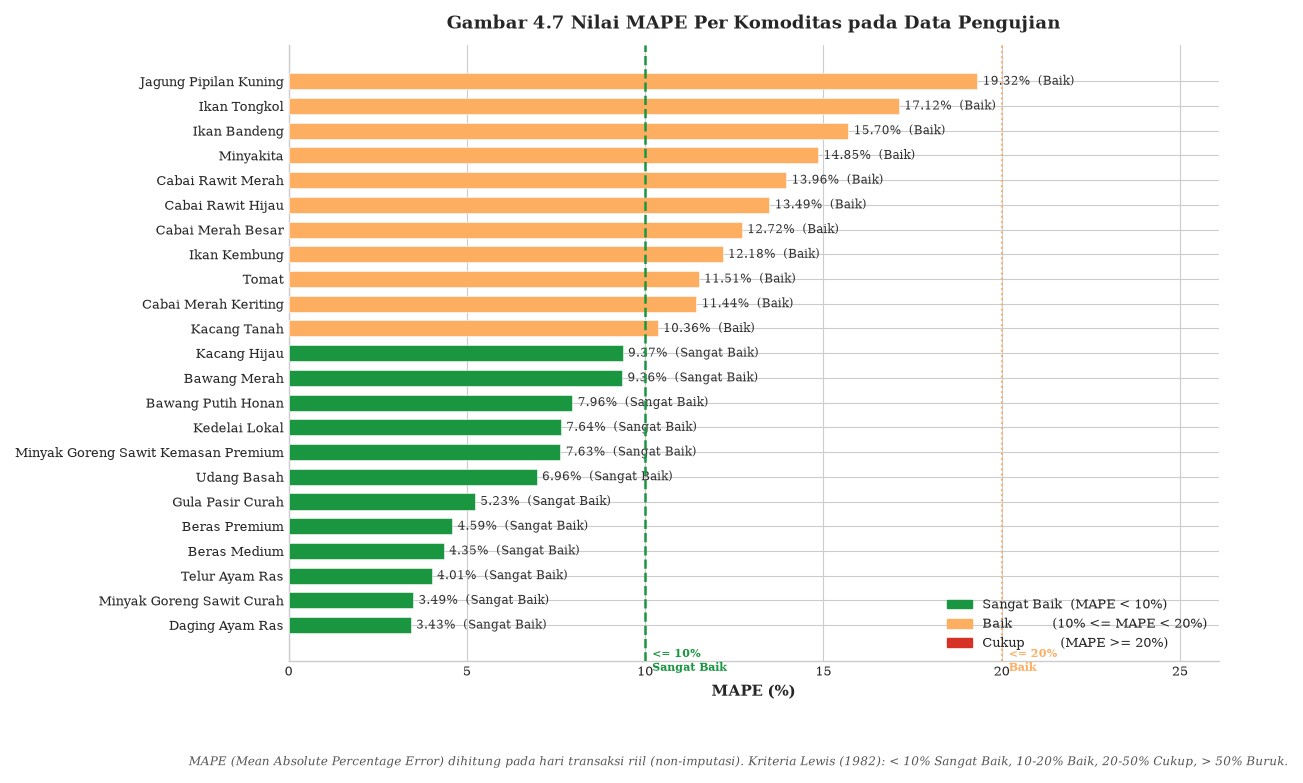

In [11]:
df_mape = df_eval[["Komoditas", "MAPE_Pct", "Kategori"]].copy()
df_mape = df_mape.sort_values("MAPE_Pct", ascending=True).reset_index(drop=True)

def mape_color(val):
    if val < 10: return C_GREEN
    if val < 20: return C_GOLD
    return C_RED

colors_mape = [mape_color(v) for v in df_mape["MAPE_Pct"]]
def fmt_label(s): return s.replace("_", " ").title()

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(df_mape["Komoditas"].apply(fmt_label), df_mape["MAPE_Pct"], color=colors_mape, height=0.65, edgecolor="white", linewidth=0.4, zorder=3)

for bar, val, kat in zip(bars, df_mape["MAPE_Pct"], df_mape["Kategori"]):
    ax.text(val + 0.15, bar.get_y() + bar.get_height() / 2, f"{val:.2f}%  ({kat})", va="center", ha="left", fontsize=8.5, color=C_DARK)

ax.axvline(10, color=C_GREEN, linewidth=1.8, linestyle="--", zorder=4, label="Batas Sangat Baik (MAPE = 10%)")
ax.axvline(20, color=C_GOLD, linewidth=1.4, linestyle=":", zorder=4, label="Batas Baik (MAPE = 20%)")

ax.text(10.2, -0.9, "<= 10%\nSangat Baik", fontsize=8, color=C_GREEN, fontweight="bold", va="top")
ax.text(20.2, -0.9, "<= 20%\nBaik", fontsize=8, color=C_GOLD, fontweight="bold", va="top")

ax.set_xlabel("MAPE (%)", fontsize=11, fontweight="bold")
ax.set_title("Gambar 4.7 Nilai MAPE Per Komoditas pada Data Pengujian", fontsize=13, fontweight="bold", pad=12)
ax.set_xlim(0, df_mape["MAPE_Pct"].max() * 1.35)

legend_patches = [
    mpatches.Patch(color=C_GREEN, label="Sangat Baik  (MAPE < 10%)"),
    mpatches.Patch(color=C_GOLD,  label="Baik          (10% <= MAPE < 20%)"),
    mpatches.Patch(color=C_RED,   label="Cukup         (MAPE >= 20%)"),
]
ax.legend(handles=legend_patches, loc="lower right", framealpha=0.95, fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(0.5, -0.02, "MAPE (Mean Absolute Percentage Error) dihitung pada hari transaksi riil (non-imputasi). Kriteria Lewis (1982): < 10% Sangat Baik, 10-20% Baik, 20-50% Cukup, > 50% Buruk.", ha="center", fontsize=8.5, style="italic", color="#555555")

save_fig(fig, "gambar_4_7.png")